# Calibration method benchmark

This notebook compares alternative ways to turn aggregate VID reaches and Reference-ID overlaps into calibrated union reach. It is separate from the campaign-scenario notebook so that the implementation choices and their tradeoffs can be evaluated directly.

The benchmark asks three different questions:

1. **Pairwise accuracy:** can the method calibrate a report containing two EDPs?
2. **Union accuracy at scale:** how accurately does it estimate union reach for five and ten EDPs?
3. **Higher-order accuracy:** how close are its inferred three-way, four-way, and five-plus-way intersections?

These are not equivalent. A method can estimate final union reach reasonably well without recovering every individual higher-order intersection accurately.

## The pairwise-inference option

For every EDP pair (i,j), first estimate its Reference-ID capture rate using a frozen campaign-size model. Two forms are tested:

\[
\operatorname{logit}(c_{ij})=a_{ij}+b\ln(x)
\]

and the simpler direct form

\[
c_{ij}=\operatorname{clip}\left(a_{ij}+b\ln(x),0,1\right).
\]

The calibrated pair overlap is \(\hat I_{ij}=J_{ij}/c_{ij}\), where \(J_{ij}\) is the collision-adjusted Reference-ID overlap. The system then finds the maximum-entropy audience distribution that preserves every per-EDP reach and calibrated pair overlap. This supplies one coherent set of three-way through ten-way intersections without depending on sparse direct high-order matches.

Pairwise information does **not** mathematically determine the higher orders. Maximum entropy is an explicit “least additional structure” assumption. An oracle diagnostic supplies the true synthetic pair overlaps to show how much error remains even when pair calibration is perfect.

In [1]:
from pathlib import Path
import csv
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display


def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd() / "synthetic_validation"]
    for candidate in candidates:
        if (candidate / "src" / "reference_calibration").exists():
            return candidate.resolve()
    raise RuntimeError("Run from the repository root or notebooks/.")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "method_benchmark_final"


def markdown_table(rows, columns):
    header = "| " + " | ".join(label for _, label in columns) + " |"
    separator = "|" + "|".join("---" for _ in columns) + "|"
    body = [
        "| " + " | ".join(str(row[key]).replace("|", "/") for key, _ in columns) + " |"
        for row in rows
    ]
    return "\n".join([header, separator, *body])


print("Project: repository root")
print(f"Benchmark outputs: {OUTPUT_DIR.relative_to(PROJECT_ROOT)}")

Project: repository root
Benchmark outputs: outputs/method_benchmark_final


## Reproduce the benchmark

The checked-in results use the full profile: 30,000 synthetic people representing 120 million people, 24 broad-reach calibration campaigns, eight whole-campaign holdouts, 13 stress scenarios, three campaigns per scenario, six report shapes, and up to ten EDPs.

Set `RUN_BENCHMARK` to `True` to rerun it. A full run takes several minutes. Leaving it `False` loads the existing results immediately.

In [2]:
RUN_BENCHMARK = False

if RUN_BENCHMARK:
    from reference_calibration.method_benchmark import run_method_benchmark
    run_method_benchmark(
        OUTPUT_DIR,
        profile="full",
        campaigns_per_scenario=3,
    )

summary = json.loads((OUTPUT_DIR / "method_summary.json").read_text())
with (OUTPUT_DIR / "method_metrics.csv").open() as stream:
    metrics = list(csv.DictReader(stream))

print(f"Methods: {summary['method_count']}")
print(f"Stress scenarios: {summary['scenario_count']}")
print(f"Detailed metric rows: {len(metrics):,}")

Methods: 18
Stress scenarios: 13
Detailed metric rows: 17,982


## Methods tested

The first eight calibrated methods change the capture-rate model but retain the original divide-then-reconcile workflow. The pairwise methods deliberately discard direct higher-order Reference-ID measurements after calibrating all pairs. The joint methods fit one audience table against all observed Reference-ID patterns. The Bayesian row is a deterministic Poisson-likelihood/MAP approximation rather than a full MCMC implementation.

In [3]:
method_rows = [
    {
        "method": method["label"],
        "category": method["category"],
        "parameters": method["parameter_count"],
        "description": method["explanation"],
    }
    for method in summary["methods"]
]
display(Markdown(markdown_table(
    method_rows,
    [
        ("method", "Method"),
        ("category", "Type"),
        ("parameters", "Parameters"),
        ("description", "What changes"),
    ],
)))

| Method | Type | Parameters | What changes |
|---|---|---|---|
| Existing VID | baseline | 0 | Population-rate overlap using the per-EDP VID reaches. |
| Pair-aware fixed | capture curve | 53 | Constant bounded capture rates with pair-specific effects. |
| Pair-aware fixed + shared log | capture curve | 54 | Pair-specific effects plus one campaign-size slope. |
| Pair-aware order-specific log | capture curve | 62 | A separate campaign-size slope for every intersection order. |
| Shape-constrained scale spline | capture curve | 57 | A smooth monotone campaign-size response instead of one log slope. |
| Hierarchical EDP + pair effects | capture curve | 63 | EDP main effects plus strongly pooled pair residuals. |
| Low-rank EDP affinity | capture curve | 40 | Two shared dimensions represent recurring EDP affinity patterns. |
| Two-group mixture | capture mixture | 21 | Two fixed person-level matchability groups. |
| Three-group mixture | capture mixture | 32 | Adds a middle matchability group to the two-group model. |
| Pairwise inference: logit calibration | pairwise inference | 54 calibration + 55 report | Calibrate only the 45 pairs, then infer all higher orders by maximum entropy. |
| Pairwise inference: direct calibration | pairwise inference | 46 calibration + 55 report | Uses bounded c=a+b log(size) pair calibration before maximum-entropy inference. |
| Pairwise inference: two-group mixture | pairwise inference | 21 calibration + 55 report | Uses the two-group mixture to calibrate pairs, then infers higher orders by maximum entropy. |
| Oracle pairwise closure (diagnostic) | diagnostic oracle | Unavailable in production | Uses true synthetic pairs to isolate the irreducible error from inferring higher orders from pairs. |
| Joint two-group pattern decoder | joint decoder | 21 | Fits all true Venn cells directly to the observed multi-EDP Reference-ID patterns. |
| Joint three-group pattern decoder | joint decoder | 32 | Joint pattern decoding with three person-level matchability groups. |
| Joint low-rank inclusive decoder | joint decoder | 40 | Fits one audience table to all inclusive overlaps using low-rank capture rates. |
| Joint mixture + low-rank affinity | joint decoder | 21 + rank-2 affinity | Adds repeatable EDP-pair residual affinity to the joint mixture response. |
| Bayesian/MAP joint affinity | Bayesian benchmark | 21 + rank-2 affinity + cell prior | Poisson-IRLS MAP approximation with a weak prior around the baseline audience table. |

## Overall union-reach result

Methods are ranked by mean absolute union-reach error across the 13 stress scenarios and six report shapes. The oracle is shown separately because it uses synthetic truth unavailable in production.

In [4]:
production_methods = [
    method for method in summary["methods"]
    if method["category"] != "diagnostic oracle"
]
ranking = sorted(production_methods, key=lambda method: method["stress_union"]["mean"])
ranking_rows = []
for rank, method in enumerate(ranking, 1):
    name = method["name"]
    ranking_rows.append({
        "rank": rank,
        "method": method["label"],
        "mean": f"{method['stress_union']['mean']:.1%}",
        "p90": f"{method['stress_union']['p90']:.1%}",
        "holdout": f"{method['holdout_union']['mean']:.1%}",
        "runtime": f"{1000 * method['mean_runtime_seconds']:.1f} ms",
    })

display(Markdown(markdown_table(
    ranking_rows,
    [
        ("rank", "Rank"),
        ("method", "Method"),
        ("mean", "Stress mean error"),
        ("p90", "Stress p90"),
        ("holdout", "Broad holdout mean"),
        ("runtime", "Mean runtime/report"),
    ],
)))

| Rank | Method | Stress mean error | Stress p90 | Broad holdout mean | Mean runtime/report |
|---|---|---|---|---|---|
| 1 | Pairwise inference: two-group mixture | 9.6% | 21.9% | 3.1% | 14.3 ms |
| 2 | Pairwise inference: direct calibration | 11.2% | 23.9% | 0.8% | 8.0 ms |
| 3 | Pairwise inference: logit calibration | 17.1% | 39.2% | 1.4% | 7.4 ms |
| 4 | Joint low-rank inclusive decoder | 18.0% | 35.7% | 0.8% | 67.0 ms |
| 5 | Joint mixture + low-rank affinity | 18.2% | 39.7% | 2.5% | 178.1 ms |
| 6 | Three-group mixture | 18.3% | 44.0% | 1.3% | 62.1 ms |
| 7 | Joint two-group pattern decoder | 18.5% | 35.7% | 3.0% | 124.2 ms |
| 8 | Joint three-group pattern decoder | 18.9% | 34.6% | 1.2% | 147.7 ms |
| 9 | Pair-aware fixed | 19.3% | 46.8% | 2.1% | 64.2 ms |
| 10 | Two-group mixture | 20.1% | 47.1% | 3.0% | 63.1 ms |
| 11 | Bayesian/MAP joint affinity | 20.6% | 34.1% | 1.6% | 336.6 ms |
| 12 | Pair-aware order-specific log | 21.8% | 54.9% | 1.6% | 63.7 ms |
| 13 | Hierarchical EDP + pair effects | 21.9% | 54.8% | 1.2% | 64.0 ms |
| 14 | Low-rank EDP affinity | 22.6% | 53.4% | 0.7% | 62.4 ms |
| 15 | Shape-constrained scale spline | 23.1% | 55.3% | 1.2% | 64.3 ms |
| 16 | Pair-aware fixed + shared log | 23.4% | 57.8% | 1.4% | 64.1 ms |
| 17 | Existing VID | 40.1% | 91.5% | 0.3% | 0.0 ms |

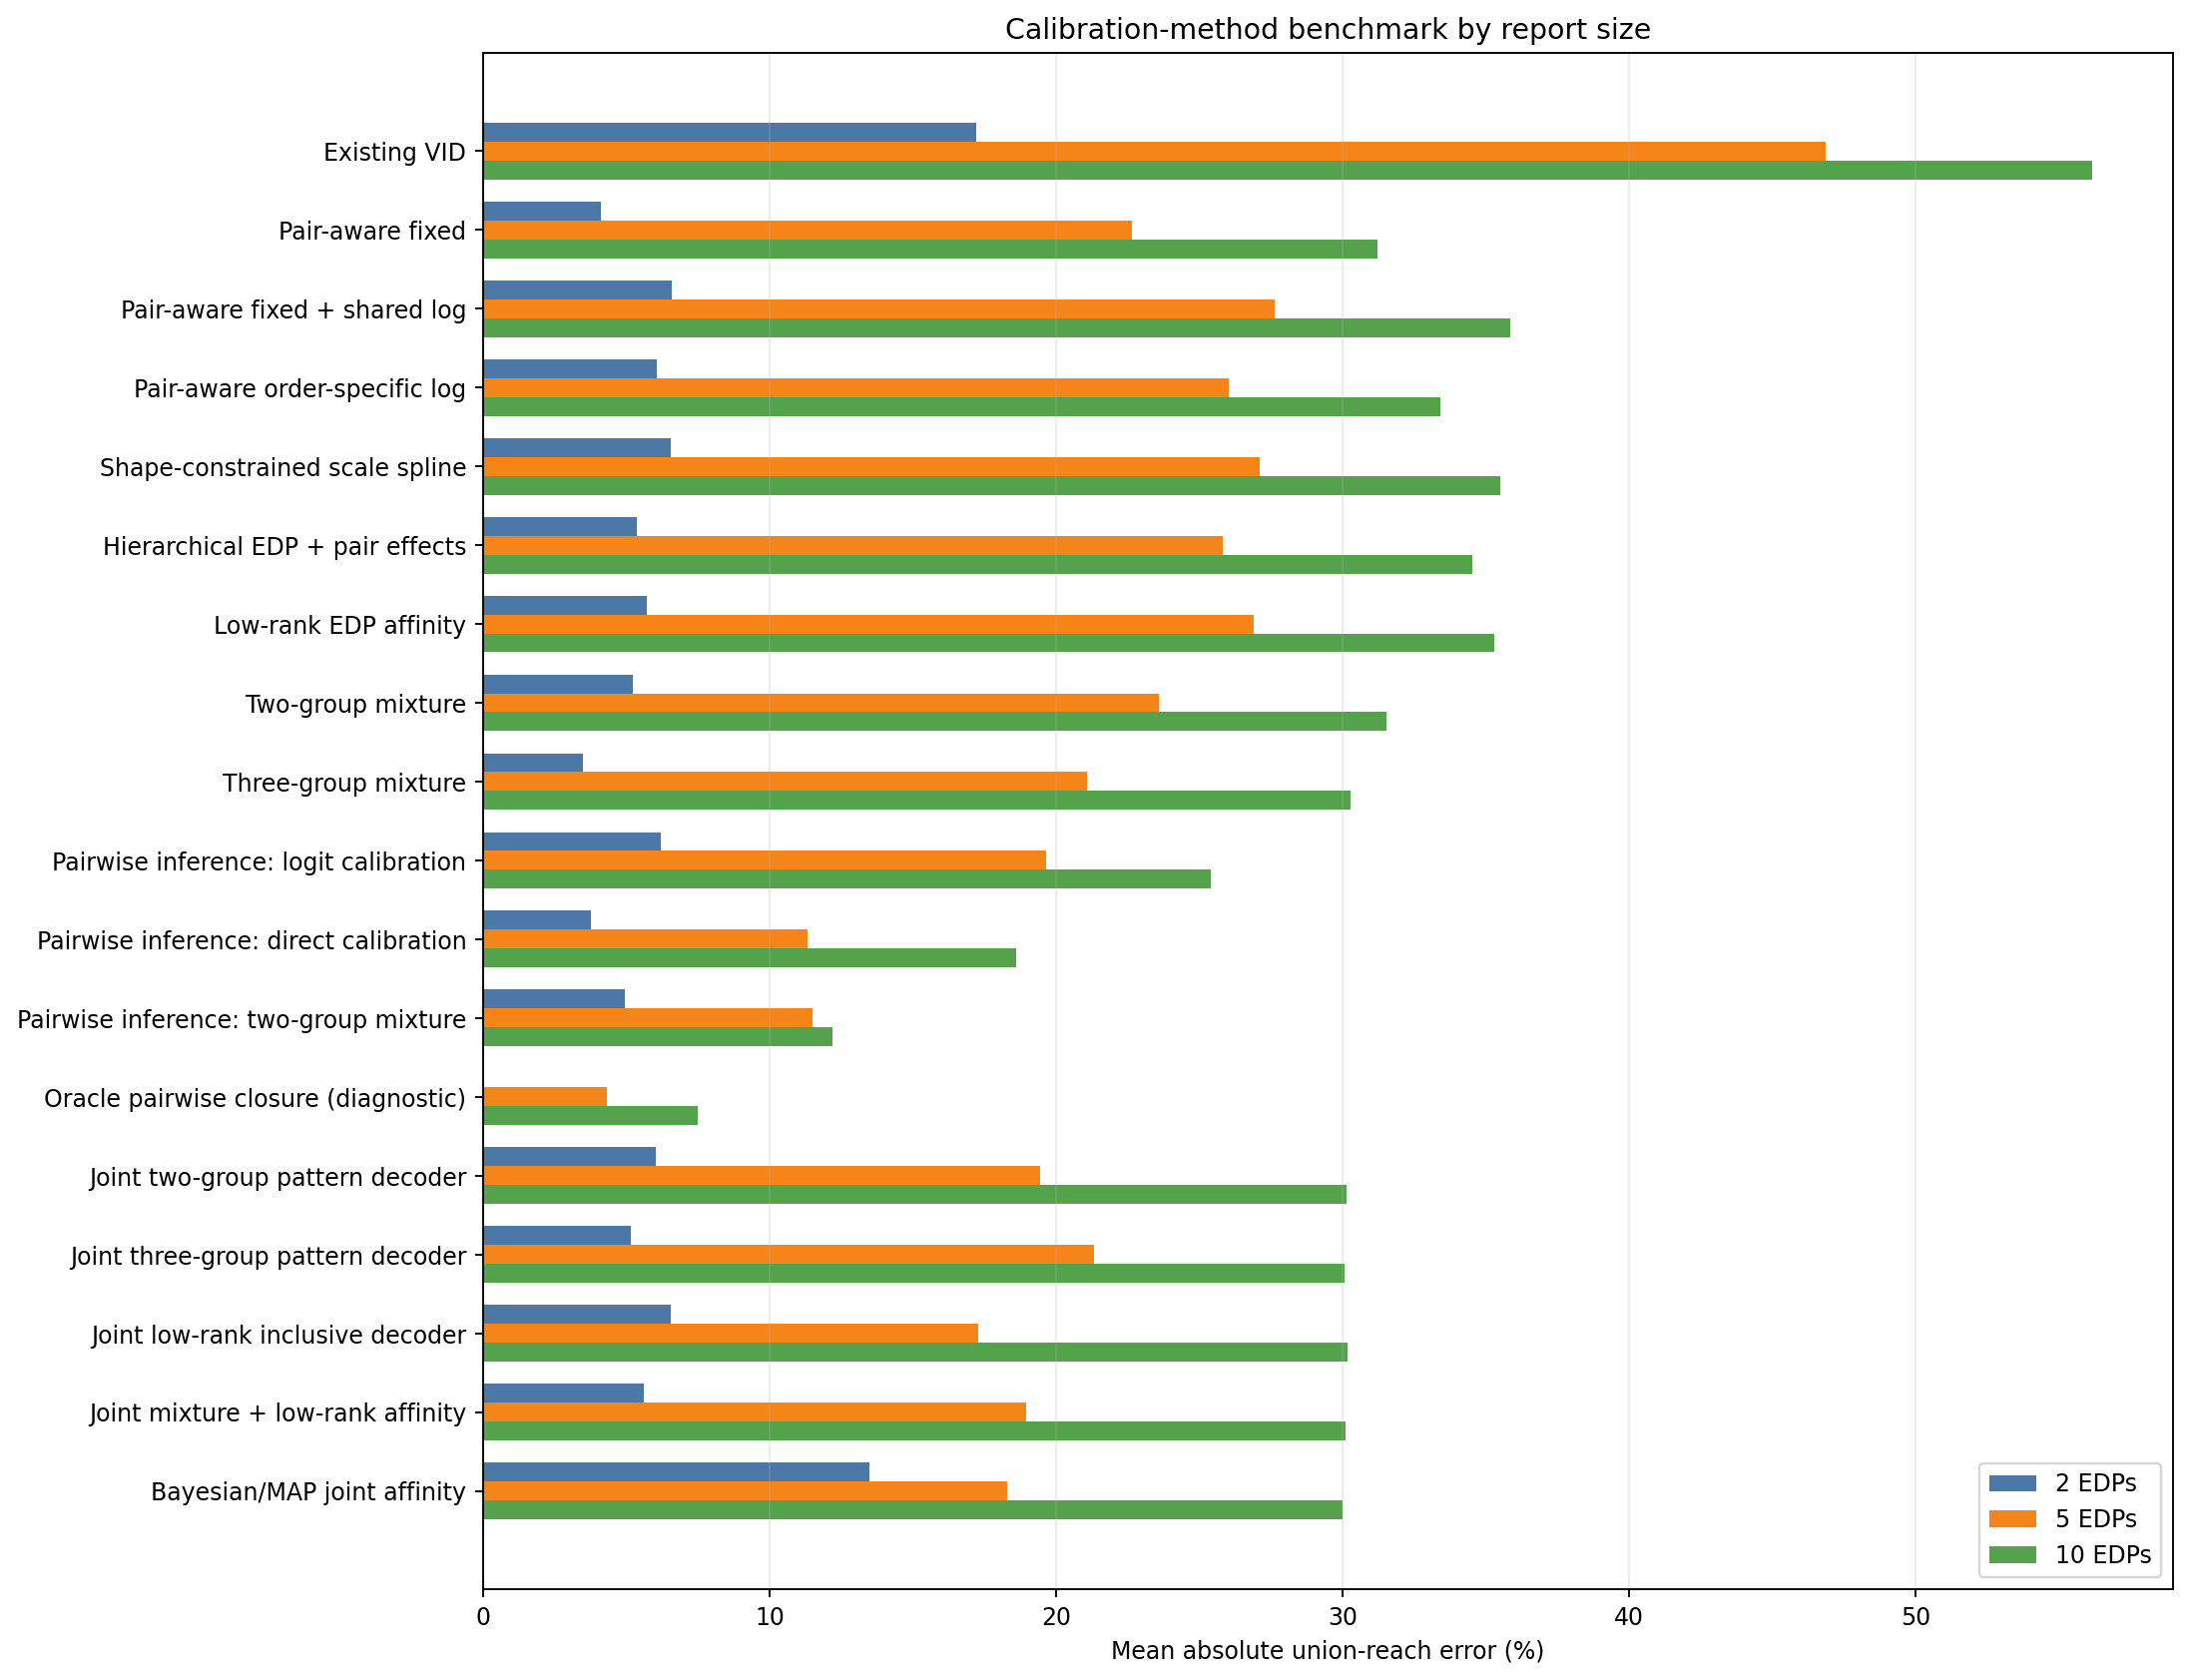

In [5]:
display(Image(filename=str(OUTPUT_DIR / "union_error_by_method.png")))

## Pairwise versus five- and ten-EDP union accuracy

This is the clean answer to whether the candidate methods improve pairwise measurements or only higher-order reports. The two-EDP column measures pairwise union directly; the other columns show how the same method scales.

In [6]:
selected_names = [
    "baseline_vid",
    "pair_fixed_divide",
    "pair_log_shared_divide",
    "three_group_divide",
    "pairwise_maxent_logit",
    "pairwise_maxent_direct",
    "pairwise_maxent_mixture",
    "oracle_pairwise_maxent",
    "joint_low_rank_inclusive",
    "joint_mixture_affinity",
    "bayesian_map_affinity",
]
lookup = {method["name"]: method for method in summary["methods"]}
size_rows = []
for name in selected_names:
    method = lookup[name]
    size_rows.append({
        "method": method["label"],
        "two": f"{summary['union_by_edp_count']['2'][name]['mean']:.1%}",
        "five": f"{summary['union_by_edp_count']['5'][name]['mean']:.1%}",
        "ten": f"{summary['union_by_edp_count']['10'][name]['mean']:.1%}",
    })

display(Markdown(markdown_table(
    size_rows,
    [
        ("method", "Method"),
        ("two", "2-EDP union error"),
        ("five", "5-EDP union error"),
        ("ten", "10-EDP union error"),
    ],
)))

| Method | 2-EDP union error | 5-EDP union error | 10-EDP union error |
|---|---|---|---|
| Existing VID | 17.2% | 46.9% | 56.2% |
| Pair-aware fixed | 4.1% | 22.6% | 31.2% |
| Pair-aware fixed + shared log | 6.6% | 27.6% | 35.9% |
| Three-group mixture | 3.5% | 21.1% | 30.3% |
| Pairwise inference: logit calibration | 6.2% | 19.6% | 25.4% |
| Pairwise inference: direct calibration | 3.8% | 11.3% | 18.6% |
| Pairwise inference: two-group mixture | 5.0% | 11.5% | 12.2% |
| Oracle pairwise closure (diagnostic) | 0.0% | 4.3% | 7.5% |
| Joint low-rank inclusive decoder | 6.5% | 17.3% | 30.2% |
| Joint mixture + low-rank affinity | 5.6% | 18.9% | 30.1% |
| Bayesian/MAP joint affinity | 13.5% | 18.3% | 30.0% |

## Intersection accuracy by order

This chart is not another union metric. It measures the weighted absolute error of the final internally consistent intersections at each order. “5+ way” combines fifth- through tenth-order intersections. A pairwise closure can produce good union reach while individual high-order intersections remain uncertain.

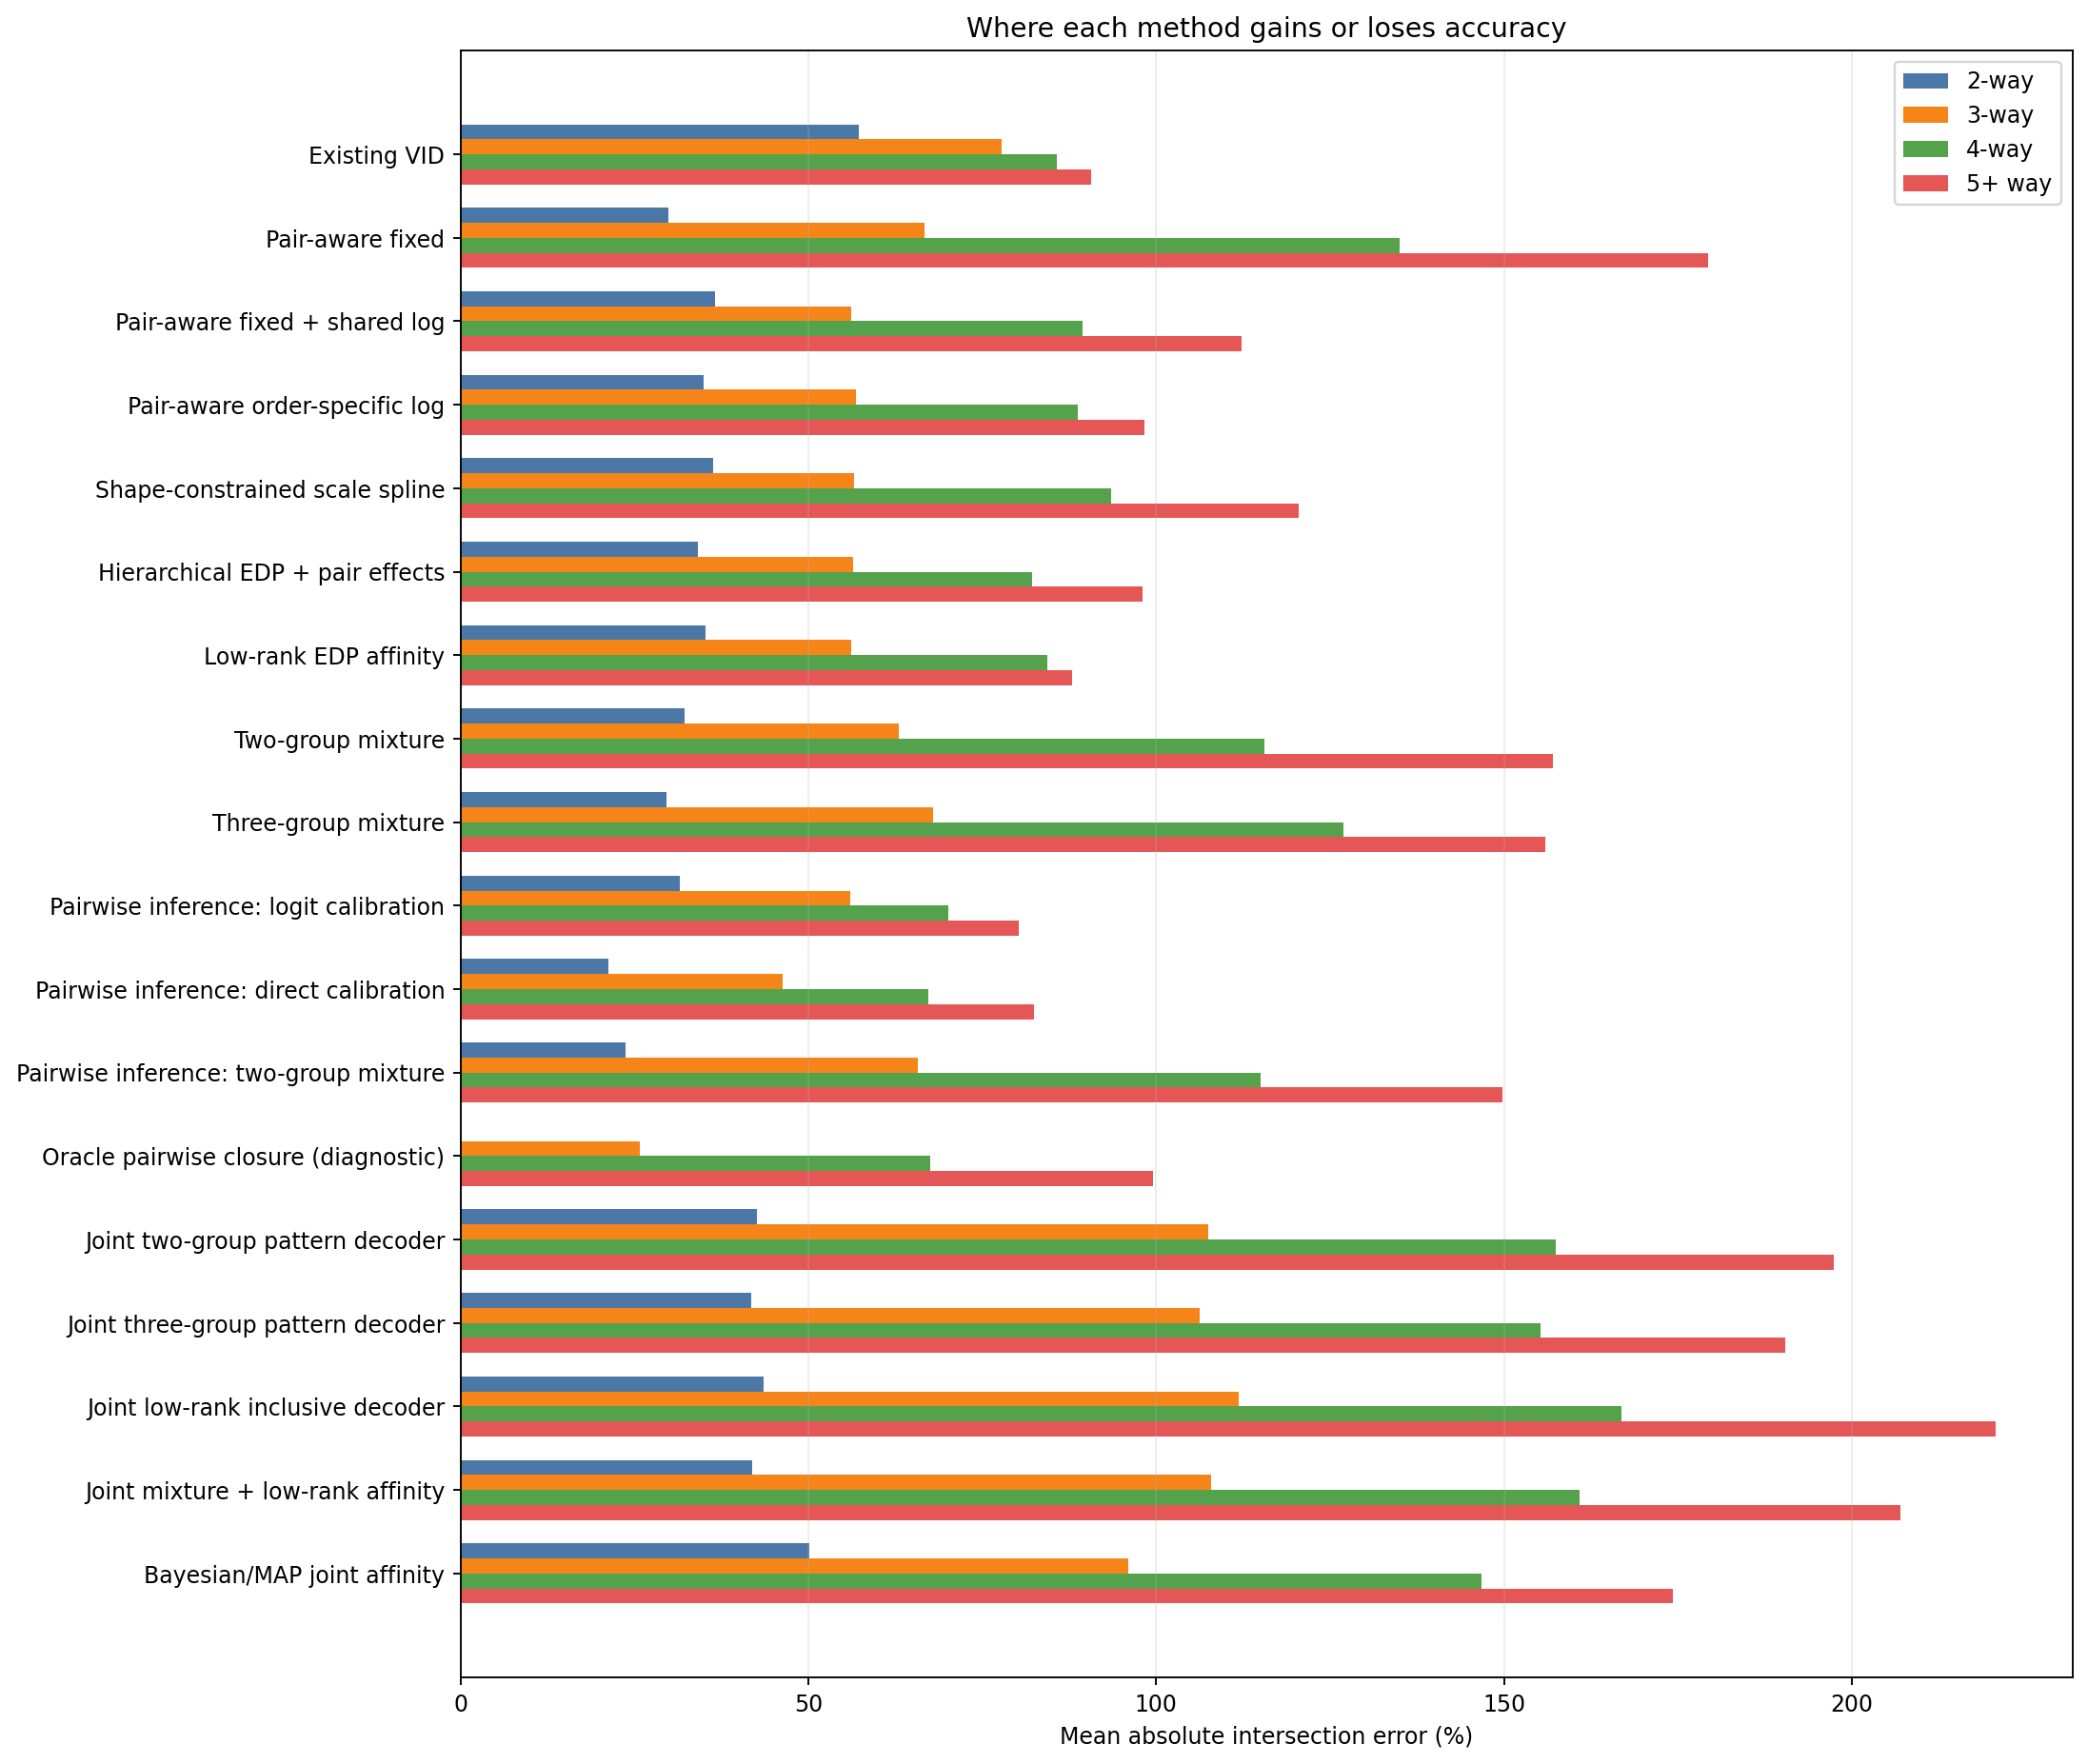

In [7]:
display(Image(filename=str(OUTPUT_DIR / "intersection_error_by_method.png")))

In [8]:
order_rows = []
for name in selected_names:
    method = lookup[name]
    order_rows.append({
        "method": method["label"],
        "pair": f"{summary['intersection_by_order']['2'][name]['mean']:.1%}",
        "three": f"{summary['intersection_by_order']['3'][name]['mean']:.1%}",
        "four": f"{summary['intersection_by_order']['4'][name]['mean']:.1%}",
        "higher": f"{summary['intersection_by_order']['5'][name]['mean']:.1%}",
    })
display(Markdown(markdown_table(
    order_rows,
    [
        ("method", "Method"),
        ("pair", "Pairwise intersection"),
        ("three", "Three-way"),
        ("four", "Four-way"),
        ("higher", "Five-way and higher"),
    ],
)))

| Method | Pairwise intersection | Three-way | Four-way | Five-way and higher |
|---|---|---|---|---|
| Existing VID | 57.2% | 77.7% | 85.7% | 90.7% |
| Pair-aware fixed | 29.9% | 66.7% | 135.0% | 179.3% |
| Pair-aware fixed + shared log | 36.5% | 56.1% | 89.5% | 112.2% |
| Three-group mixture | 29.6% | 67.9% | 126.9% | 155.9% |
| Pairwise inference: logit calibration | 31.5% | 56.0% | 70.0% | 80.3% |
| Pairwise inference: direct calibration | 21.2% | 46.3% | 67.2% | 82.4% |
| Pairwise inference: two-group mixture | 23.7% | 65.7% | 115.0% | 149.8% |
| Oracle pairwise closure (diagnostic) | 0.0% | 25.7% | 67.5% | 99.5% |
| Joint low-rank inclusive decoder | 43.5% | 111.8% | 166.9% | 220.7% |
| Joint mixture + low-rank affinity | 42.0% | 107.9% | 160.9% | 206.9% |
| Bayesian/MAP joint affinity | 50.1% | 95.9% | 146.7% | 174.3% |

## What pairwise inference can and cannot recover

The oracle pairwise method uses the true synthetic pair overlaps and then performs the same maximum-entropy higher-order inference. Its remaining error is evidence that pairs alone do not identify the exact higher-order audience structure. The difference between the production pairwise method and the oracle indicates how much opportunity remains in pair calibration—although the two errors can occasionally cancel, so this is a diagnostic rather than a formal decomposition.

In [9]:
scenario_rows = []
for scenario, values in summary["union_by_scenario"].items():
    baseline = values["baseline_vid"]["mean"]
    direct = values["pairwise_maxent_direct"]["mean"]
    oracle = values["oracle_pairwise_maxent"]["mean"]
    joint = values["joint_low_rank_inclusive"]["mean"]
    scenario_rows.append({
        "scenario": scenario.replace("_", " "),
        "baseline": f"{baseline:.1%}",
        "direct": f"{direct:.1%}",
        "oracle": f"{oracle:.1%}",
        "joint": f"{joint:.1%}",
        "pair_gap": f"{direct - oracle:+.1%}",
    })

display(Markdown(markdown_table(
    scenario_rows,
    [
        ("scenario", "Scenario"),
        ("baseline", "Existing VID"),
        ("direct", "Direct pair + inference"),
        ("oracle", "Oracle pairs + inference"),
        ("joint", "Joint low-rank"),
        ("pair_gap", "Direct minus oracle"),
    ],
)))

| Scenario | Existing VID | Direct pair + inference | Oracle pairs + inference | Joint low-rank | Direct minus oracle |
|---|---|---|---|---|---|
| broad awareness control | 0.5% | 2.6% | 0.0% | 4.4% | +2.6% |
| traffic optimization | 6.4% | 5.8% | 0.3% | 9.1% | +5.5% |
| video engagement retargeting | 40.2% | 19.8% | 6.0% | 11.1% | +13.8% |
| lead generation | 36.7% | 4.8% | 5.7% | 6.5% | -1.0% |
| sales prospecting | 33.7% | 4.8% | 4.4% | 7.1% | +0.4% |
| website retargeting | 101.6% | 20.6% | 10.8% | 45.8% | +9.8% |
| crm customer list | 132.2% | 15.9% | 9.8% | 60.9% | +6.1% |
| catalog retargeting | 43.0% | 6.8% | 1.9% | 9.9% | +4.9% |
| lookalike prospecting | 18.9% | 6.8% | 1.8% | 9.0% | +5.0% |
| advantage audience expansion | 16.5% | 4.5% | 1.5% | 8.2% | +3.0% |
| app activity retargeting | 77.8% | 42.3% | 8.9% | 33.3% | +33.4% |
| unrelated niche control | 11.6% | 6.5% | 0.1% | 19.4% | +6.4% |
| mixed funnel portfolio | 2.0% | 4.9% | 0.0% | 9.3% | +4.9% |

## Findings

1. **Pairwise calibration followed by maximum-entropy inference is the strongest tested family.** The two-group mixture version has 9.6% mean stress error, the direct fixed-plus-log version has 11.2%, and the existing VID baseline has 40.1%.
2. **The two pair calibrations have different strengths.** The direct model is slightly better for two and five EDPs—3.8% and 11.3% versus 5.0% and 11.5%—while the mixture is substantially better at ten EDPs: 12.2% versus 18.6%.
3. **Inferring higher orders from pairs is useful but not exact.** With perfect synthetic pair overlaps, mean error is 0.0% for two EDPs, 4.3% for five, and 7.5% for ten. That remaining error is the price of not directly knowing the higher-order structure.
4. **The app-retargeting case is primarily a pair-calibration transfer problem.** Direct and mixture pairwise calibration have 42.3% and 38.6% mean error, whereas oracle pairs reduce it to 8.9%.
5. **Website and customer-list retargeting contain both problems.** Better pair calibration helps substantially, but even oracle pairs leave roughly 10% error because those scenarios have strong higher-order structure.
6. **More flexible campaign-size curves did not solve the main issue.** The spline, order-specific log, hierarchical pair, and low-rank capture curves all remained around 22–23% mean stress error with the original divide-then-reconcile decoder.
7. **The tested Bayesian/MAP decoder is not currently worth its complexity.** It was slower and less accurate on average than direct pairwise inference. That rejects this implementation, not every possible Bayesian capture-recapture model.
8. **Broad and already-well-modeled reports need a fallback.** Existing VID remains best on the broad-reach holdout and on the broad-awareness control. The direct pair model is also safer than the mixture on broad holdouts—0.8% versus 3.1% mean error—so the apparent ten-EDP advantage of the mixture must be validated on real non-reach campaigns.

## Recommendation

Advance two candidates to real-data validation: **bounded direct pair fixed-plus-log plus maximum-entropy inference**, and **two-group mixture pair calibration plus the same inference step**. The direct model is simpler and safer on broad holdouts; the mixture performed better on the most difficult ten-EDP synthetic reports. The current synthetic evidence is not strong enough to choose between them for production.

Before production selection:

- fit and compare the direct and logit pair models using approved aggregate records from real campaigns;
- validate customer-list, website-retargeting, app, lead, sales, lookalike, and broad-reach campaigns as separate holdout strata;
- establish an observable activation or fallback rule so broad campaigns retain the existing VID result when correction is not supported;
- report uncertainty that includes both pair-calibration error and the irreducible range of higher-order structures compatible with the calibrated pairs; and
- retain direct higher-order Reference-ID measurements as diagnostics, even if the production point estimate is primarily inferred from pairs.